# Chapter 15: Curves

Source orientation: printed pages 383-428; physical PDF pages 400-445. This notebook uses the source span only to choose the mathematical coverage: curve representations, parameterization, arc length, continuity, piecewise polynomial curves, cubic constraints, Bézier curves, de Casteljau evaluation, B-spline basis functions, nonuniform knots, repeated knots, and NURBS. The explanations, code, diagrams, and checks are original course material.

## Chapter question

How can a graphics program specify a smooth curve in a way that is easy to draw, edit, evaluate, and validate?

The chapter's answer is representational. The same point set can be described implicitly, parametrically, or procedurally, but graphics workflows usually prefer parametric pieces because sampling and interpolation are direct. The hidden danger is that the free parameter is not automatically distance along the curve. A point halfway through parameter space may be nowhere near halfway along the visible stroke. Once curves are built from pieces, the next danger is continuity: pieces can connect in position while still having a corner, or they can share tangent direction but move at different speeds.

## Translation guide

- **Curve vs representation**: a curve is a point set; a representation is a computational way to name or generate that set.
- **Parameterization**: a map from an interval to points. Reparameterization changes the timing without changing the traced set.
- **Arc-length parameter**: a parameter whose derivative has constant magnitude, usually obtained numerically for free-form curves.
- **Continuity**: `C0` means positions match, `C1` means derivatives match, and `G1` means tangent directions match even if speeds differ.
- **Polynomial pieces**: local curve segments joined by constraints; cubic pieces are popular because they balance control and flexibility.
- **Bézier curve**: a polynomial curve controlled by Bernstein weights and evaluated stably by de Casteljau subdivision.
- **B-spline**: a linear combination of local basis functions defined by a knot vector; bases sum to one and provide locality.
- **NURBS**: rational B-spline curves that attach weights to control points, letting conic sections be represented exactly.

## Visual storyboard and library routing

| Order | Artifact | Concept | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | `curve-representation-route-map.png` | implicit, parametric, procedural, piecewise | route map and examples | Matplotlib | which representation answers which computational question | implicit residual and sample count |
| 2 | `parameterization-arc-length-diagnostics.png` | timing vs shape | same curve, different speeds | NumPy + Matplotlib | equal-parameter points are not equal-distance points | arc-length table monotonicity |
| 3 | `piecewise-continuity-constraints.png` | C0, C1, G1 joins | joined polynomial pieces | Matplotlib | positions, derivatives, tangent directions at joins | continuity residual table |
| 4 | `cubic-basis-constraint-comparison.png` | Hermite, Lagrange, Bézier cubic forms | basis-function plots | SymPy + Matplotlib | constraints and basis sums | basis partition-of-unity checks |
| 5 | `bezier-de-casteljau-subdivision.png` | Bézier control polygon and stable evaluation | de Casteljau construction | Matplotlib | nested linear interpolation and convex hull | de Casteljau equals Bernstein |
| 6 | `bspline-basis-locality-knots.png` | Cox-de Boor basis, local support, partition of unity | basis and curve plots | NumPy + Matplotlib | only a few basis functions are active | basis sum and locality checks |
| 7 | `repeated-knots-nurbs-circle.png` | knot repetition and rational weights | endpoint/interior interpolation and NURBS quarter circle | Matplotlib | smoothness tradeoff and conic exactness | repeated-knot interpolation and radius residual |
| 8 | `curve-control-lab.html` | Bézier and B-spline control comparison | interactive Plotly lab | Plotly | control polygon influence and local support | artifact and sample checks |


In [1]:
from pathlib import Path
import math
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np
import plotly.graph_objects as go
import sympy as sp

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_nonblank_image

CHAPTER = 15
TITLE = "Curves"
UNIT = f"chapter-{CHAPTER:02d}"
SOURCE_SPAN = "printed pages 383-428; physical PDF pages 400-445"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for child in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 170, "font.size": 10})
COLORS = {"blue":"#2b6cb0", "teal":"#008080", "orange":"#d97706", "red":"#c53030", "green":"#2f855a", "purple":"#6b46c1", "gray":"#4a5568", "light":"#edf2f7"}
image_paths = []
html_paths = []
table_paths = []
check_paths = []
checks = {}

def remember(path, kind):
    if kind == "image": image_paths.append(path)
    elif kind == "html": html_paths.append(path)
    elif kind == "table": table_paths.append(path)
    elif kind == "check": check_paths.append(path)
    return path

def rel_book(path):
    p = Path(path)
    if not p.is_absolute() and p.parts and p.parts[0] == "artifacts":
        return p.as_posix()
    try:
        return p.resolve().relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return p.as_posix()

def style_axis(ax, title, xlabel=None, ylabel=None, equal=False):
    ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, color="#e2e8f0", lw=0.8)
    if equal: ax.set_aspect("equal", adjustable="box")

def bezier_bernstein(points, u):
    pts = np.asarray(points, dtype=float)
    u = np.asarray(u, dtype=float)
    n = len(pts) - 1
    out = np.zeros((u.size, pts.shape[1]))
    for i, p in enumerate(pts):
        out += math.comb(n, i) * ((1-u) ** (n-i) * u ** i)[:, None] * p
    return out

def de_casteljau(points, u):
    levels = [np.asarray(points, dtype=float)]
    cur = levels[0]
    for _ in range(1, len(points)):
        cur = (1-u) * cur[:-1] + u * cur[1:]
        levels.append(cur)
    return levels[-1][0], levels

def bspline_basis(i, k, knots, t):
    knots = np.asarray(knots, dtype=float)
    t = np.asarray(t, dtype=float)
    if k == 1:
        mask = (knots[i] <= t) & (t < knots[i+1])
        if i + 1 == len(knots) - 1:
            mask = mask | np.isclose(t, knots[-1])
        return mask.astype(float)
    denom1 = knots[i+k-1] - knots[i]
    denom2 = knots[i+k] - knots[i+1]
    term1 = 0 if denom1 == 0 else ((t - knots[i]) / denom1) * bspline_basis(i, k-1, knots, t)
    term2 = 0 if denom2 == 0 else ((knots[i+k] - t) / denom2) * bspline_basis(i+1, k-1, knots, t)
    return term1 + term2

def bspline_curve(control, k, knots, t):
    control = np.asarray(control, dtype=float)
    basis = np.vstack([bspline_basis(i, k, knots, t) for i in range(len(control))]).T
    return basis @ control, basis

def rational_quadratic(points, weights, u):
    pts = np.asarray(points, dtype=float)
    w = np.asarray(weights, dtype=float)
    u = np.asarray(u, dtype=float)
    B = np.vstack([(1-u)**2, 2*(1-u)*u, u**2]).T
    numerator = (B * w[None, :]) @ pts
    denominator = (B * w[None, :]).sum(axis=1)
    return numerator / denominator[:, None]


## 1. Representation map: curves answer different questions

An implicit curve answers membership: does this point satisfy `f(x,y)=0`? A parametric curve answers evaluation: where is the point at parameter `u`? A procedural or generative curve answers construction: how do repeated rules create points? For rendering and modeling, parametric pieces are attractive because they can be sampled and edited, while implicit forms are attractive for testing and collision-like queries.

The first figure puts these routes side by side using synthetic examples. The circle appears both implicitly and parametrically to emphasize that the representation is not the curve itself.


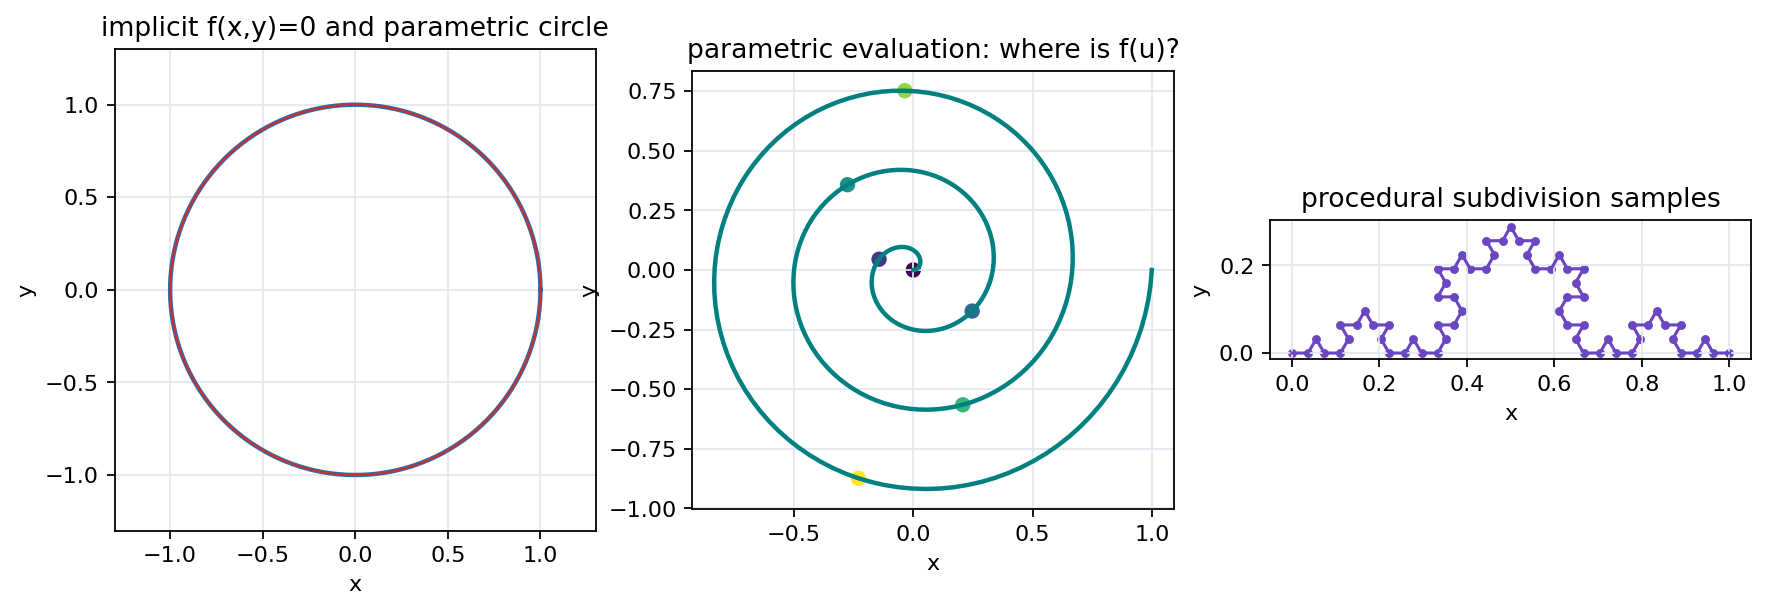

In [2]:
u = np.linspace(0, 1, 300)
theta = 2*np.pi*u
circle = np.c_[np.cos(theta), np.sin(theta)]
spiral = np.c_[u*np.cos(6*np.pi*u), u*np.sin(6*np.pi*u)]
# Koch-like generative polyline, tiny and deterministic.
poly = np.array([[0.0, 0.0], [1.0, 0.0]])
for _ in range(3):
    new = []
    for a, b in zip(poly[:-1], poly[1:]):
        v = b - a
        p1 = a + v/3
        p3 = a + 2*v/3
        rot = np.array([[0.5, -math.sqrt(3)/2], [math.sqrt(3)/2, 0.5]])
        p2 = p1 + rot @ (v/3)
        new.extend([a, p1, p2, p3])
    new.append(poly[-1])
    poly = np.array(new)
implicit_residual = np.max(np.abs(np.sum(circle**2, axis=1)-1))
checks["implicit_circle_parametric_residual"] = float(implicit_residual)
checks["procedural_curve_sample_count"] = int(len(poly))

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0))
axes[0].plot(circle[:,0], circle[:,1], color=COLORS["blue"], lw=2)
axes[0].contour(np.linspace(-1.3,1.3,80), np.linspace(-1.3,1.3,80), (lambda X,Y: X*X+Y*Y-1)(*np.meshgrid(np.linspace(-1.3,1.3,80), np.linspace(-1.3,1.3,80))), levels=[0], colors=[COLORS["red"]], linewidths=1.0)
style_axis(axes[0], "implicit f(x,y)=0 and parametric circle", "x", "y", True)
axes[1].plot(spiral[:,0], spiral[:,1], color=COLORS["teal"], lw=2)
axes[1].scatter(spiral[::45,0], spiral[::45,1], c=u[::45], cmap="viridis", s=35)
style_axis(axes[1], "parametric evaluation: where is f(u)?", "x", "y", True)
axes[2].plot(poly[:,0], poly[:,1], color=COLORS["purple"], lw=1.4)
axes[2].scatter(poly[:,0], poly[:,1], s=9, color=COLORS["purple"])
style_axis(axes[2], "procedural subdivision samples", "x", "y", True)
route_path = remember(save_matplotlib(fig, UNIT, "curve-representation-route-map.png"), "image")
plt.close(fig)
display_artifact(route_path, width=900)


## 2. Reparameterization changes timing, not the point set

The same visible segment can be drawn by `f(u)=(u,0)`, `f(u)=(u^2,0)`, or many other maps. The point set is unchanged, but the parameter values no longer mean the same locations. For a curved path, an arc-length table gives a practical way to recover more uniform distance samples even when a closed-form inverse is unavailable.

This diagnostic compares equal-parameter samples with equal-distance samples on a wavy curve. The shape is the same, but the dots show why animation, stroking, and texture placement often need arc-length information.


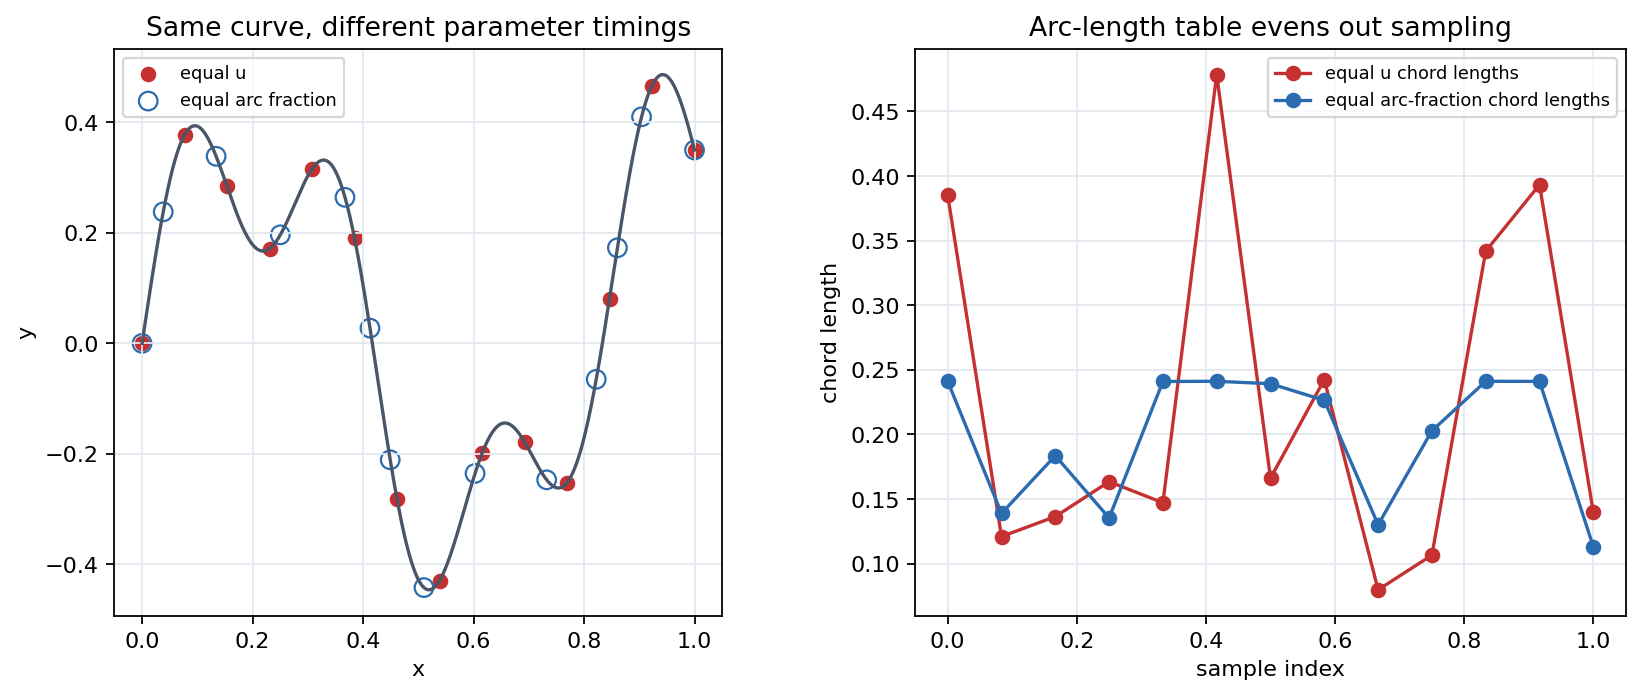

In [3]:
def curve(u):
    return np.c_[u, 0.35*np.sin(2.5*np.pi*u) + 0.18*np.sin(7*np.pi*u)]

def curve_derivative(u):
    return np.c_[np.ones_like(u), 0.35*2.5*np.pi*np.cos(2.5*np.pi*u) + 0.18*7*np.pi*np.cos(7*np.pi*u)]

u_dense = np.linspace(0, 1, 1200)
pts_dense = curve(u_dense)
seg = np.linalg.norm(np.diff(pts_dense, axis=0), axis=1)
arc = np.r_[0, np.cumsum(seg)]
arc /= arc[-1]
u_equal = np.linspace(0, 1, 14)
pts_equal_u = curve(u_equal)
u_equal_s = np.interp(np.linspace(0,1,14), arc, u_dense)
pts_equal_s = curve(u_equal_s)
steps_u = np.linalg.norm(np.diff(pts_equal_u, axis=0), axis=1)
steps_s = np.linalg.norm(np.diff(pts_equal_s, axis=0), axis=1)
checks["arc_length_table_monotone"] = bool(np.all(np.diff(arc) >= 0))
checks["arc_length_sampling_reduces_step_cv"] = bool(steps_s.std()/steps_s.mean() < steps_u.std()/steps_u.mean())
checks["equal_u_step_cv"] = float(steps_u.std()/steps_u.mean())
checks["equal_s_step_cv"] = float(steps_s.std()/steps_s.mean())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
axes[0].plot(pts_dense[:,0], pts_dense[:,1], color=COLORS["gray"], lw=1.5)
axes[0].scatter(pts_equal_u[:,0], pts_equal_u[:,1], color=COLORS["red"], label="equal u")
axes[0].scatter(pts_equal_s[:,0], pts_equal_s[:,1], facecolors="none", edgecolors=COLORS["blue"], s=70, label="equal arc fraction")
style_axis(axes[0], "Same curve, different parameter timings", "x", "y", True)
axes[0].legend(fontsize=8)
axes[1].plot(np.linspace(0,1,len(steps_u)), steps_u, "o-", color=COLORS["red"], label="equal u chord lengths")
axes[1].plot(np.linspace(0,1,len(steps_s)), steps_s, "o-", color=COLORS["blue"], label="equal arc-fraction chord lengths")
style_axis(axes[1], "Arc-length table evens out sampling", "sample index", "chord length")
axes[1].legend(fontsize=8)
arc_path = remember(save_matplotlib(fig, UNIT, "parameterization-arc-length-diagnostics.png"), "image")
plt.close(fig)
display_artifact(arc_path, width=900)


## 3. Piecewise continuity contracts

A piecewise curve is useful only if neighboring pieces meet in the way the modeler expects. `C0` checks position. `C1` checks the actual derivative vector. `G1` checks only tangent direction, so it permits different speeds through the join. These distinctions matter in graphics because a visible corner, a speed jump, and a tangent-direction jump are different artifacts.

The panels below show three joins. The check table records position, derivative, and tangent-direction residuals at the shared endpoint.


C:\Users\rahul\AppData\Local\Temp\ipykernel_1816\108110494.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  gres=float(abs(np.cross(da,db))/(np.linalg.norm(da)*np.linalg.norm(db)))


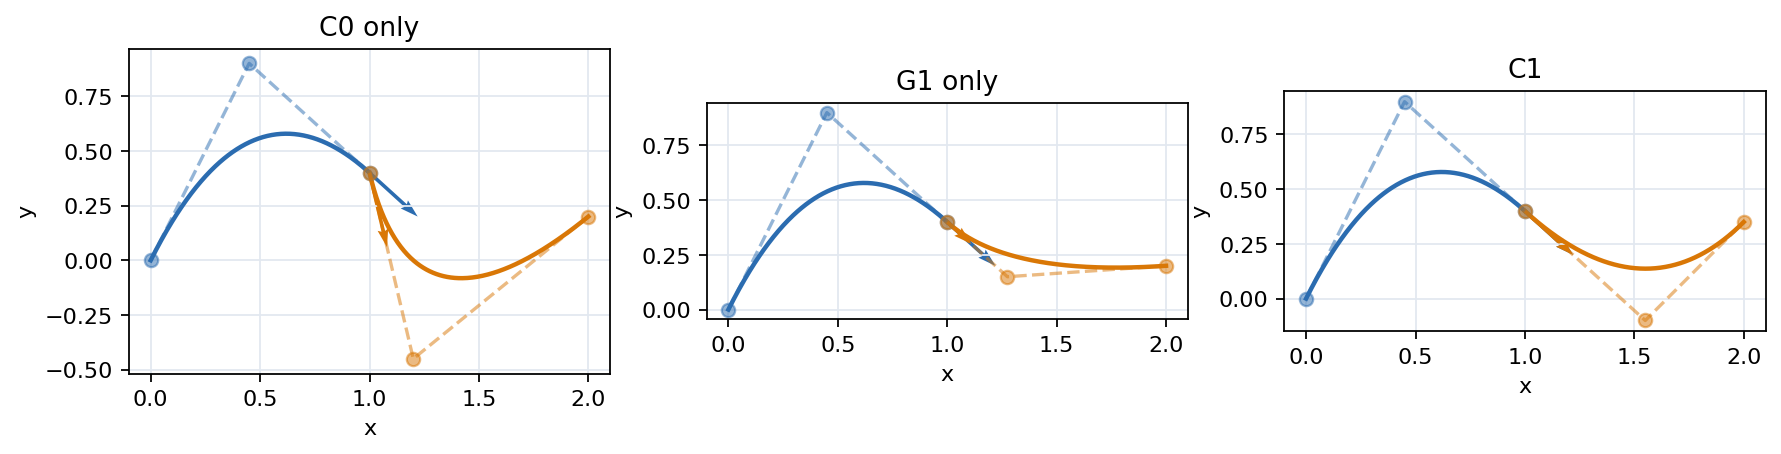

In [4]:
def quad(p0, p1, p2, u):
    u = np.asarray(u)
    return ((1-u)**2)[:,None]*p0 + (2*(1-u)*u)[:,None]*p1 + (u**2)[:,None]*p2

def quad_derivative(p0,p1,p2,u):
    return 2*(1-u)[:,None]*(p1-p0) + 2*u[:,None]*(p2-p1)

joins = [
    ("C0 only", np.array([[0,0],[0.45,0.9],[1,0.4]]), np.array([[1,0.4],[1.2,-0.45],[2,0.2]])),
    ("G1 only", np.array([[0,0],[0.45,0.9],[1,0.4]]), np.array([[1,0.4],[1.275,0.15],[2,0.2]])),
    ("C1", np.array([[0,0],[0.45,0.9],[1,0.4]]), np.array([[1,0.4],[1.55,-0.1],[2,0.35]])),
]
rows=[]
fig, axes = plt.subplots(1,3,figsize=(13.2,4.0))
for ax,(name,a,b) in zip(axes,joins):
    ca=quad(a[0],a[1],a[2],u)
    cb=quad(b[0],b[1],b[2],u)
    da=quad_derivative(a[0],a[1],a[2],np.array([1.0]))[0]
    db=quad_derivative(b[0],b[1],b[2],np.array([0.0]))[0]
    pos=float(np.linalg.norm(a[2]-b[0]))
    dres=float(np.linalg.norm(da-db))
    gres=float(abs(np.cross(da,db))/(np.linalg.norm(da)*np.linalg.norm(db)))
    rows.append({"join":name,"position_residual":pos,"derivative_residual":dres,"tangent_direction_sine":gres})
    ax.plot(ca[:,0],ca[:,1],color=COLORS["blue"],lw=2)
    ax.plot(cb[:,0],cb[:,1],color=COLORS["orange"],lw=2)
    ax.plot(a[:,0],a[:,1],"--o",color=COLORS["blue"],alpha=.5)
    ax.plot(b[:,0],b[:,1],"--o",color=COLORS["orange"],alpha=.5)
    ax.quiver([a[2,0],b[0,0]],[a[2,1],b[0,1]],[da[0],db[0]],[da[1],db[1]],angles='xy',scale_units='xy',scale=5,color=[COLORS["blue"],COLORS["orange"]])
    style_axis(ax,name,"x","y",True)
checks["continuity_c0_position_zero"] = bool(rows[0]["position_residual"] < 1e-12)
checks["continuity_g1_direction_small"] = bool(rows[1]["tangent_direction_sine"] < 1e-12)
checks["continuity_c1_derivative_small"] = bool(rows[2]["derivative_residual"] < 1e-12)
continuity_table = remember(save_table_csv(rows, UNIT, "piecewise-continuity-residuals.csv"), "table")
cont_path = remember(save_matplotlib(fig, UNIT, "piecewise-continuity-constraints.png"), "image")
plt.close(fig)
display_artifact(cont_path, width=900)
display_artifact(continuity_table)


## 4. Cubic bases encode constraints

Cubic curves are popular because four scalar degrees of freedom per coordinate can encode useful constraints: endpoints and tangents for Hermite form, interpolation sites for Lagrange form, or control points for Bézier form. The basis functions are not decoration; they tell the curve how each piece of input data influences every parameter value.

The basis plot verifies partition-of-unity for Bernstein and Lagrange cubic bases. The Hermite basis sums differently because tangent data are derivative constraints rather than point weights.


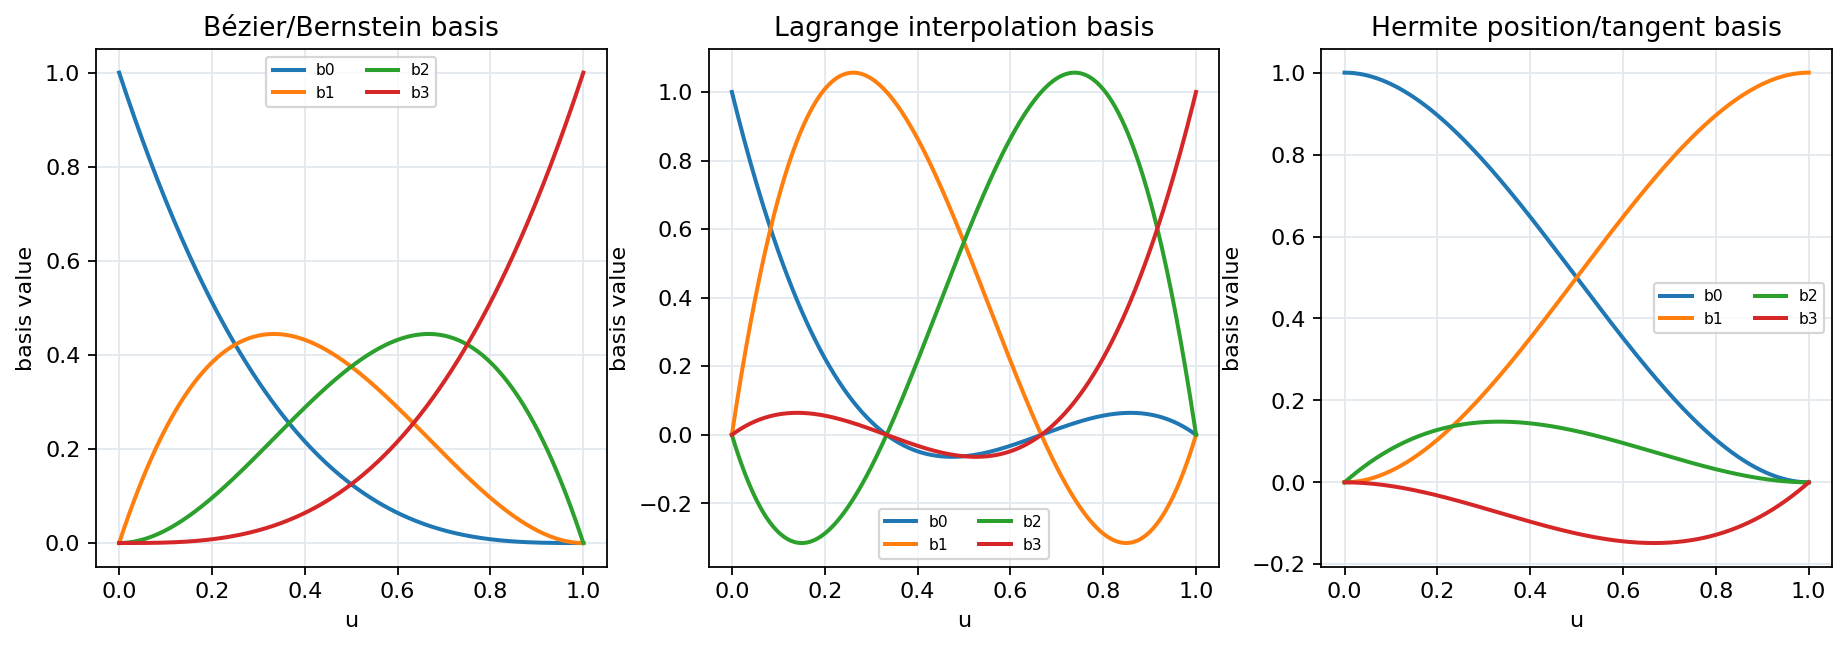

In [5]:
s = sp.symbols('s')
bern = [sp.expand(sp.binomial(3,i)*(1-s)**(3-i)*s**i) for i in range(4)]
lag_nodes = [sp.Rational(0), sp.Rational(1,3), sp.Rational(2,3), sp.Rational(1)]
lag = []
for i,xi in enumerate(lag_nodes):
    term = 1
    for j,xj in enumerate(lag_nodes):
        if i != j:
            term *= (s-xj)/(xi-xj)
    lag.append(sp.expand(term))
herm = [2*s**3-3*s**2+1, -2*s**3+3*s**2, s**3-2*s**2+s, s**3-s**2]
checks["bernstein_partition_unity_symbolic"] = bool(sp.simplify(sum(bern)-1)==0)
checks["lagrange_partition_unity_symbolic"] = bool(sp.simplify(sum(lag)-1)==0)
checks["hermite_position_basis_sum_symbolic"] = bool(sp.simplify(herm[0]+herm[1]-1)==0)
ss = np.linspace(0,1,300)
fig, axes = plt.subplots(1,3,figsize=(14,4.2))
for ax,basis,title in zip(axes,[bern,lag,herm],["Bézier/Bernstein basis","Lagrange interpolation basis","Hermite position/tangent basis"]):
    for j,f in enumerate(basis):
        vals=np.array([float(f.subs(s,x)) for x in ss])
        ax.plot(ss,vals,lw=1.8,label=f"b{j}")
    style_axis(ax,title,"u","basis value")
    ax.legend(fontsize=7,ncol=2)
basis_path = remember(save_matplotlib(fig, UNIT, "cubic-basis-constraint-comparison.png"), "image")
plt.close(fig)
display_artifact(basis_path, width=900)


## 5. Bézier curves expose control through de Casteljau subdivision

A cubic Bézier curve approximates its four control points and stays inside their convex hull. De Casteljau evaluation uses repeated linear interpolation, which is both stable and visually meaningful: every intermediate point lies on a segment between previous-level points. Subdivision at a parameter value produces two smaller Bézier curves that exactly reproduce the original curve.

The check compares de Casteljau evaluation with the Bernstein polynomial formula and records a convex-hull bounding test.


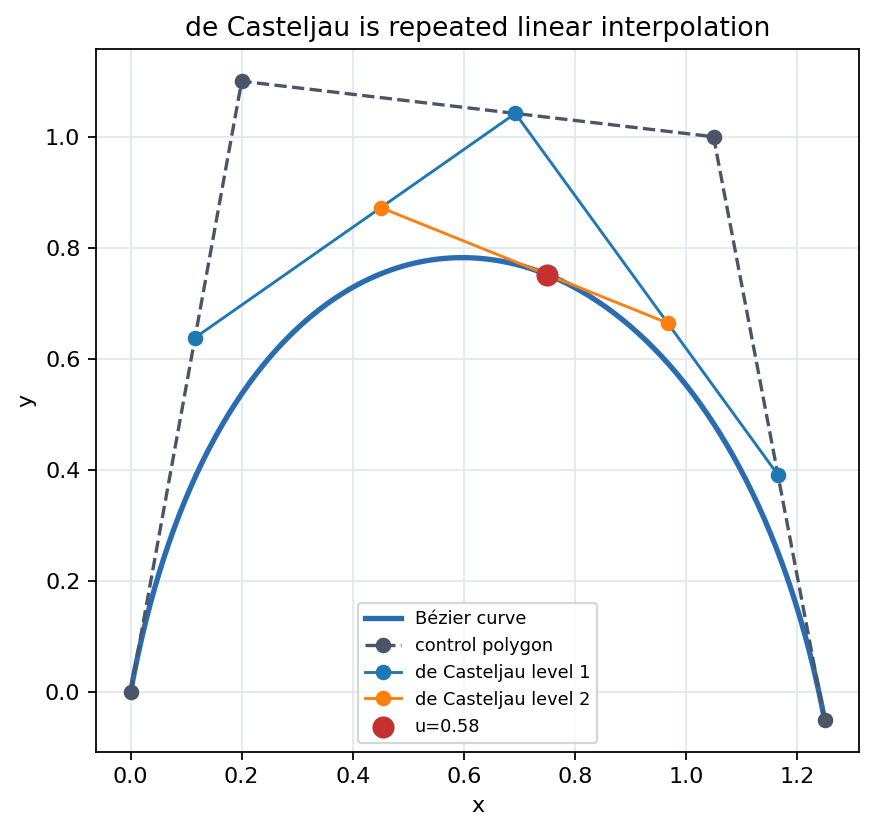

In [6]:
control = np.array([[0.0,0.0],[0.2,1.1],[1.05,1.0],[1.25,-0.05]])
bezier = bezier_bernstein(control, u)
value, levels = de_casteljau(control, 0.58)
bern_value = bezier_bernstein(control, np.array([0.58]))[0]
checks["de_casteljau_bernstein_residual"] = float(np.linalg.norm(value-bern_value))
mins=control.min(axis=0); maxs=control.max(axis=0)
checks["bezier_inside_control_bbox"] = bool(np.all(bezier >= mins-1e-12) and np.all(bezier <= maxs+1e-12))
fig, ax = plt.subplots(figsize=(7,5.7))
ax.plot(bezier[:,0],bezier[:,1],color=COLORS["blue"],lw=2.4,label="Bézier curve")
ax.plot(control[:,0],control[:,1],"--o",color=COLORS["gray"],label="control polygon")
for level,pts in enumerate(levels[1:-1], start=1):
    ax.plot(pts[:,0],pts[:,1],"o-",lw=1.3,label=f"de Casteljau level {level}")
ax.scatter([value[0]],[value[1]],s=80,color=COLORS["red"],zorder=5,label="u=0.58")
style_axis(ax,"de Casteljau is repeated linear interpolation","x","y",True)
ax.legend(fontsize=8)
bezier_path = remember(save_matplotlib(fig, UNIT, "bezier-de-casteljau-subdivision.png"), "image")
plt.close(fig)
display_artifact(bezier_path, width=720)


## 6. B-spline bases are local and sum to one

B-splines define a curve as a weighted sum of control points. The weights come from the Cox-de Boor recurrence and depend on the knot vector. At any parameter value, only a small number of basis functions are nonzero, which gives B-splines their local editing behavior. The basis functions also sum to one on the valid interval, so translating all control points translates the whole curve.

The figure uses a quadratic B-spline basis (`k=3`) and a seven-point control polygon, matching the chapter's emphasis on uniform and nonuniform B-spline properties.


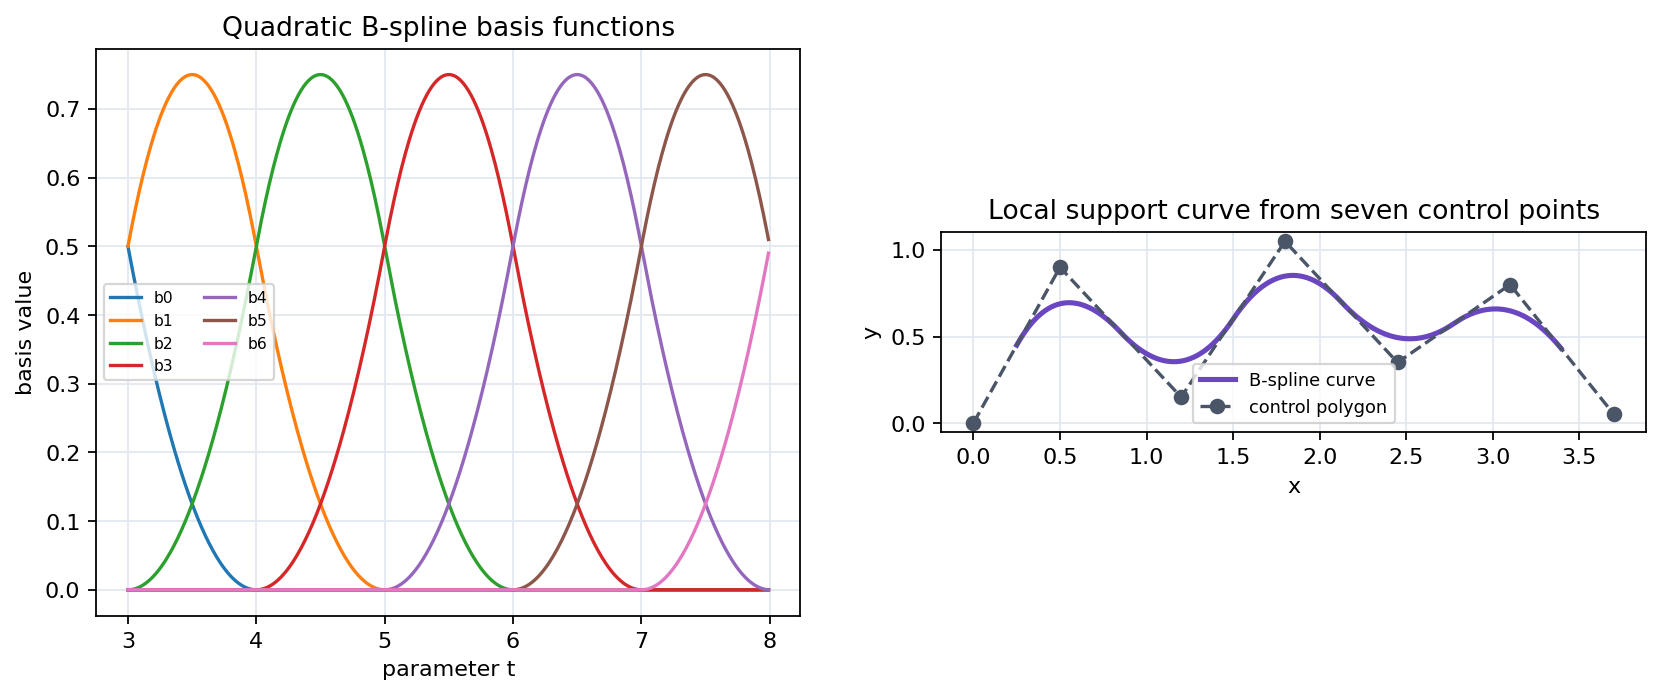

In [7]:
ctrl = np.array([[0,0],[0.5,0.9],[1.2,0.15],[1.8,1.05],[2.45,0.35],[3.1,0.8],[3.7,0.05]], dtype=float)
k=3
knots=np.arange(1, len(ctrl)+k+1, dtype=float)
tvals=np.linspace(knots[k-1], knots[len(ctrl)], 500, endpoint=False)
bs_curve, basis = bspline_curve(ctrl,k,knots,tvals)
active_counts=(basis>1e-10).sum(axis=1)
checks["bspline_partition_unity_max_error"] = float(np.max(np.abs(basis.sum(axis=1)-1)))
checks["bspline_max_active_basis_count"] = int(active_counts.max())
checks["bspline_locality_at_most_k"] = bool(active_counts.max() <= k)
fig, axes = plt.subplots(1,2,figsize=(12.5,4.6))
for i in range(basis.shape[1]):
    axes[0].plot(tvals,basis[:,i],lw=1.5,label=f"b{i}")
style_axis(axes[0],"Quadratic B-spline basis functions", "parameter t", "basis value")
axes[0].legend(fontsize=7,ncol=2)
axes[1].plot(bs_curve[:,0],bs_curve[:,1],color=COLORS["purple"],lw=2.3,label="B-spline curve")
axes[1].plot(ctrl[:,0],ctrl[:,1],"--o",color=COLORS["gray"],label="control polygon")
style_axis(axes[1],"Local support curve from seven control points", "x", "y", True)
axes[1].legend(fontsize=8)
bs_path = remember(save_matplotlib(fig, UNIT, "bspline-basis-locality-knots.png"), "image")
plt.close(fig)
display_artifact(bs_path, width=900)


## 7. Repeated knots trade smoothness for interpolation; NURBS add weights

Repeated knots can force interpolation, but the cost is reduced smoothness. That makes them useful at endpoints and at deliberately sharp features, but dangerous if smoothness is expected. NURBS go one step further by making the B-spline combination rational: control points are multiplied by weights, and the weighted numerator is divided by the weighted denominator.

The right panel uses a rational quadratic Bézier curve, a small NURBS-like example, to draw a quarter circle exactly. A nonrational quadratic Bézier with the same control points approximates the circle but does not stay at radius one.


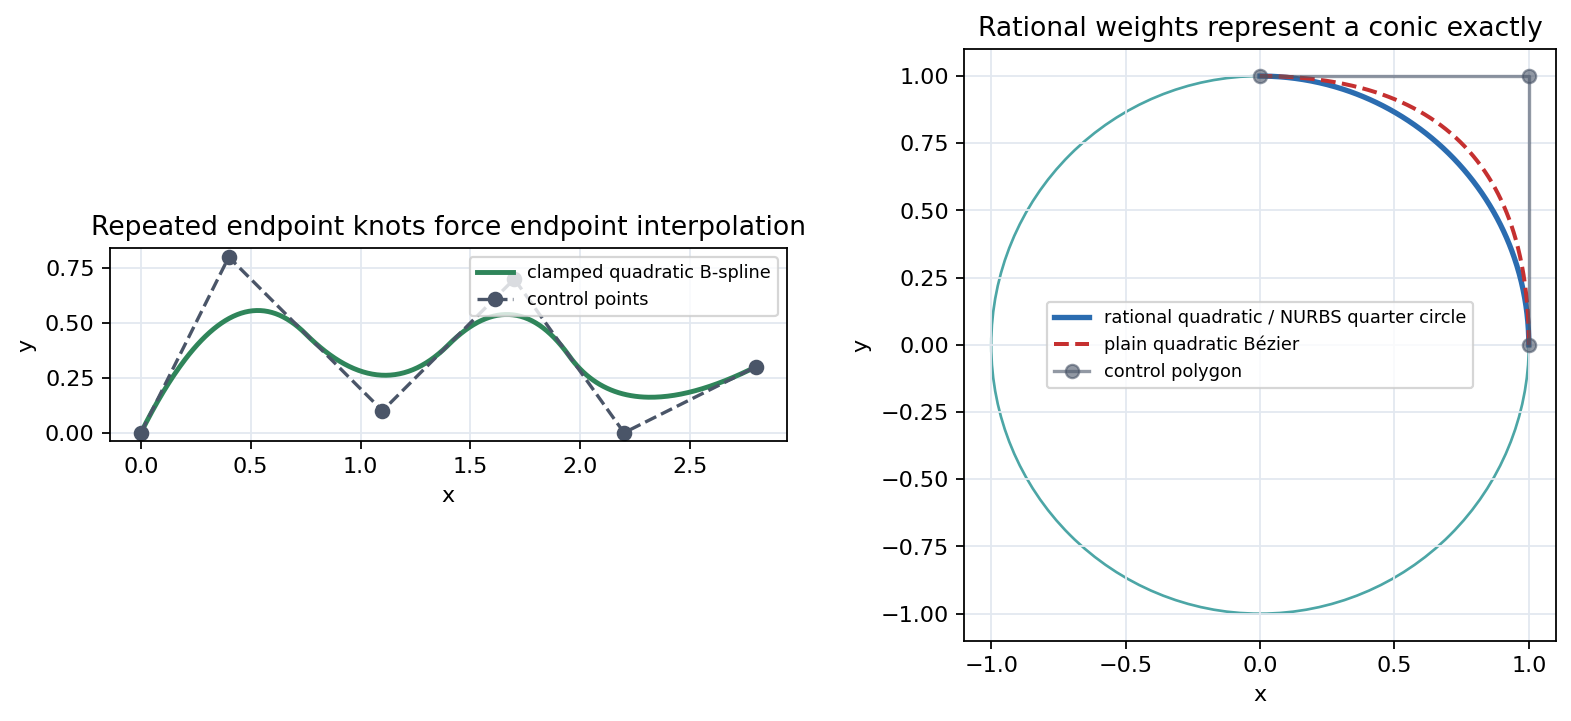

In [8]:
# Endpoint-clamped quadratic basis for repeated-knot interpolation.
clamped_knots = np.array([0,0,0,1,2,3,4,4,4], dtype=float)
ctrl2 = np.array([[0,0],[0.4,0.8],[1.1,0.1],[1.7,0.7],[2.2,0.0],[2.8,0.3]], dtype=float)
tv = np.linspace(clamped_knots[k-1], clamped_knots[len(ctrl2)], 500, endpoint=False)
clamped_curve, clamped_basis = bspline_curve(ctrl2,k,clamped_knots,tv)
checks["clamped_bspline_start_interpolates"] = bool(np.linalg.norm(clamped_curve[0]-ctrl2[0]) < 1e-12)
checks["clamped_bspline_basis_sum_error"] = float(np.max(np.abs(clamped_basis.sum(axis=1)-1)))

q_ctrl = np.array([[1,0],[1,1],[0,1]], dtype=float)
weights = np.array([1, math.sqrt(2)/2, 1])
quad_nurbs = rational_quadratic(q_ctrl, weights, u)
quad_plain = bezier_bernstein(q_ctrl, u)
radius_error = np.max(np.abs(np.sum(quad_nurbs**2, axis=1)-1))
plain_error = np.max(np.abs(np.sum(quad_plain**2, axis=1)-1))
checks["nurbs_quarter_circle_radius_residual"] = float(radius_error)
checks["plain_quadratic_circle_radius_residual"] = float(plain_error)
checks["nurbs_more_accurate_than_plain_quadratic"] = bool(radius_error < plain_error)

fig, axes = plt.subplots(1,2,figsize=(12,4.8))
axes[0].plot(clamped_curve[:,0],clamped_curve[:,1],color=COLORS["green"],lw=2.2,label="clamped quadratic B-spline")
axes[0].plot(ctrl2[:,0],ctrl2[:,1],"--o",color=COLORS["gray"],label="control points")
style_axis(axes[0],"Repeated endpoint knots force endpoint interpolation", "x", "y", True)
axes[0].legend(fontsize=8)
axes[1].plot(quad_nurbs[:,0],quad_nurbs[:,1],color=COLORS["blue"],lw=2.4,label="rational quadratic / NURBS quarter circle")
axes[1].plot(quad_plain[:,0],quad_plain[:,1],"--",color=COLORS["red"],lw=1.8,label="plain quadratic Bézier")
axes[1].plot(q_ctrl[:,0],q_ctrl[:,1],"o-",color=COLORS["gray"],alpha=.6,label="control polygon")
axes[1].add_patch(plt.Circle((0,0),1,fill=False,color=COLORS["teal"],lw=1.2,alpha=.7))
style_axis(axes[1],"Rational weights represent a conic exactly", "x", "y", True)
axes[1].legend(fontsize=8)
nurbs_path = remember(save_matplotlib(fig, UNIT, "repeated-knots-nurbs-circle.png"), "image")
plt.close(fig)
display_artifact(nurbs_path, width=880)


## Applied lab: compare Bézier and B-spline control

The HTML lab overlays the cubic Bézier control polygon with the B-spline control polygon from this notebook. Move through the traces to compare global and local influence. A single Bézier control point can affect the entire segment; a B-spline control point affects only the interval where its basis function is nonzero.


In [9]:
fig_lab = go.Figure()
fig_lab.add_trace(go.Scatter(x=bezier[:,0], y=bezier[:,1], mode='lines', name='cubic Bézier curve'))
fig_lab.add_trace(go.Scatter(x=control[:,0], y=control[:,1], mode='lines+markers', name='Bézier control polygon'))
fig_lab.add_trace(go.Scatter(x=bs_curve[:,0], y=bs_curve[:,1], mode='lines', name='quadratic B-spline curve'))
fig_lab.add_trace(go.Scatter(x=ctrl[:,0], y=ctrl[:,1], mode='lines+markers', name='B-spline control polygon'))
fig_lab.update_layout(title='Curve control lab: global Bézier segment vs local B-spline support', xaxis_title='x', yaxis_title='y', height=560, yaxis_scaleanchor='x')
lab_path = remember(save_plotly_html(fig_lab, UNIT, "curve-control-lab.html", include_plotlyjs=True), "html")
checks["curve_lab_trace_count"] = len(fig_lab.data)
display_artifact(lab_path, width="100%", height=560)


## Display the chapter artifacts

The artifact names describe the curve concept they teach rather than the plotting tool that produced them. They form a path through the chapter: representation, parameterization, continuity, cubic bases, Bézier evaluation, B-spline locality, NURBS weights, and an applied comparison lab.


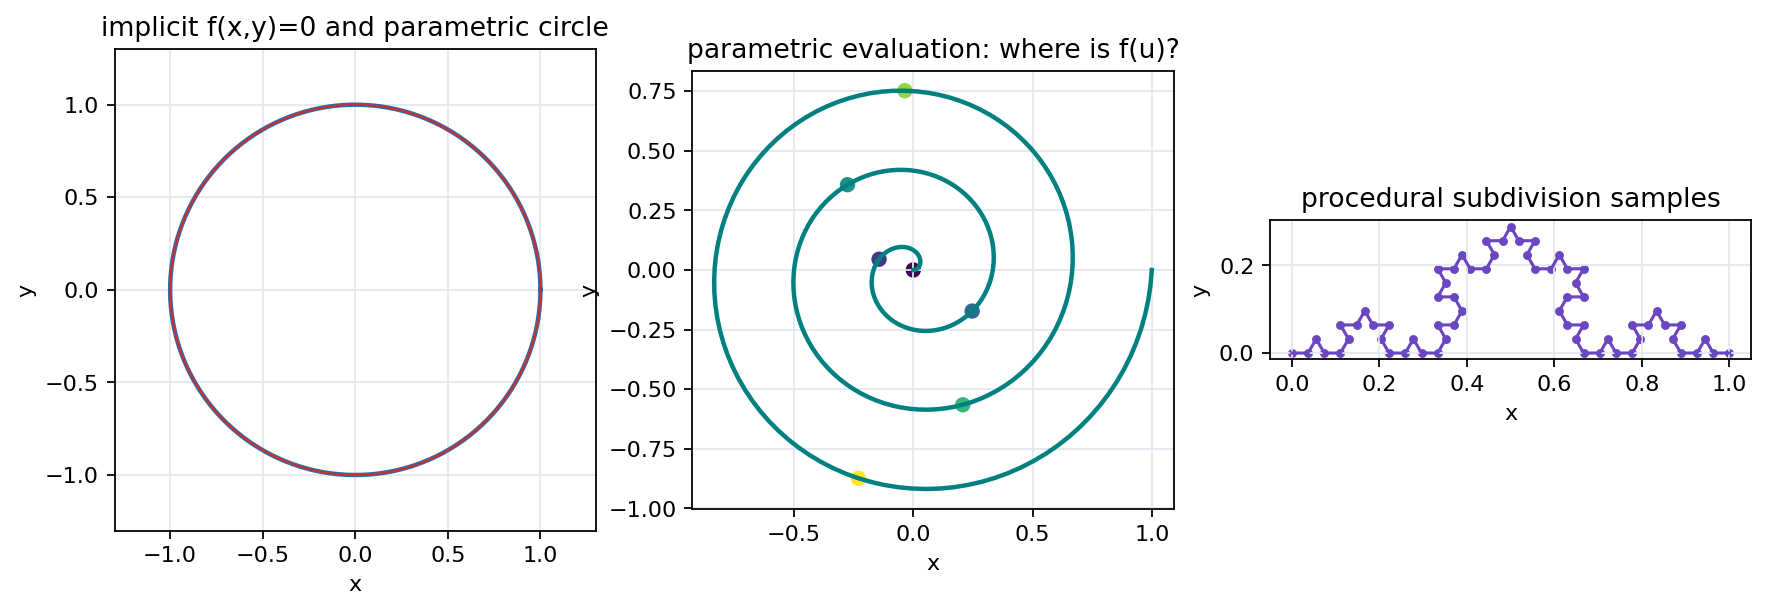

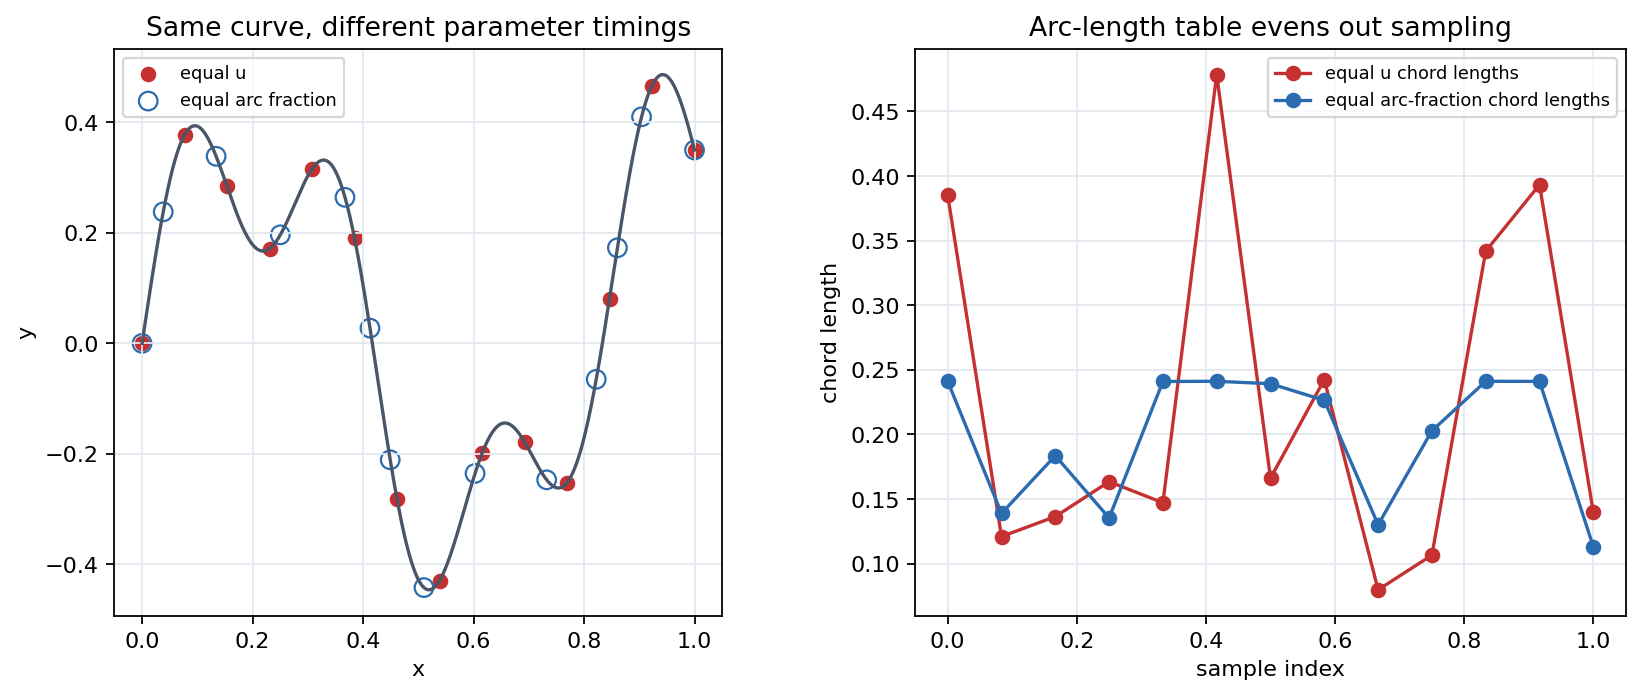

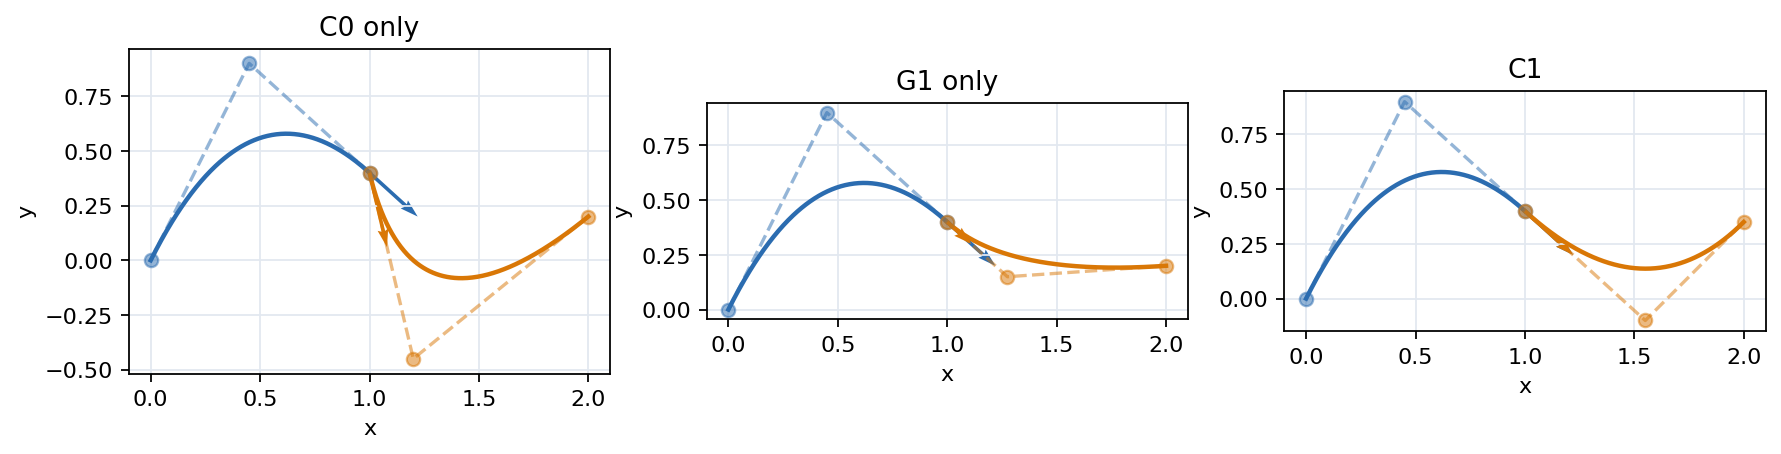

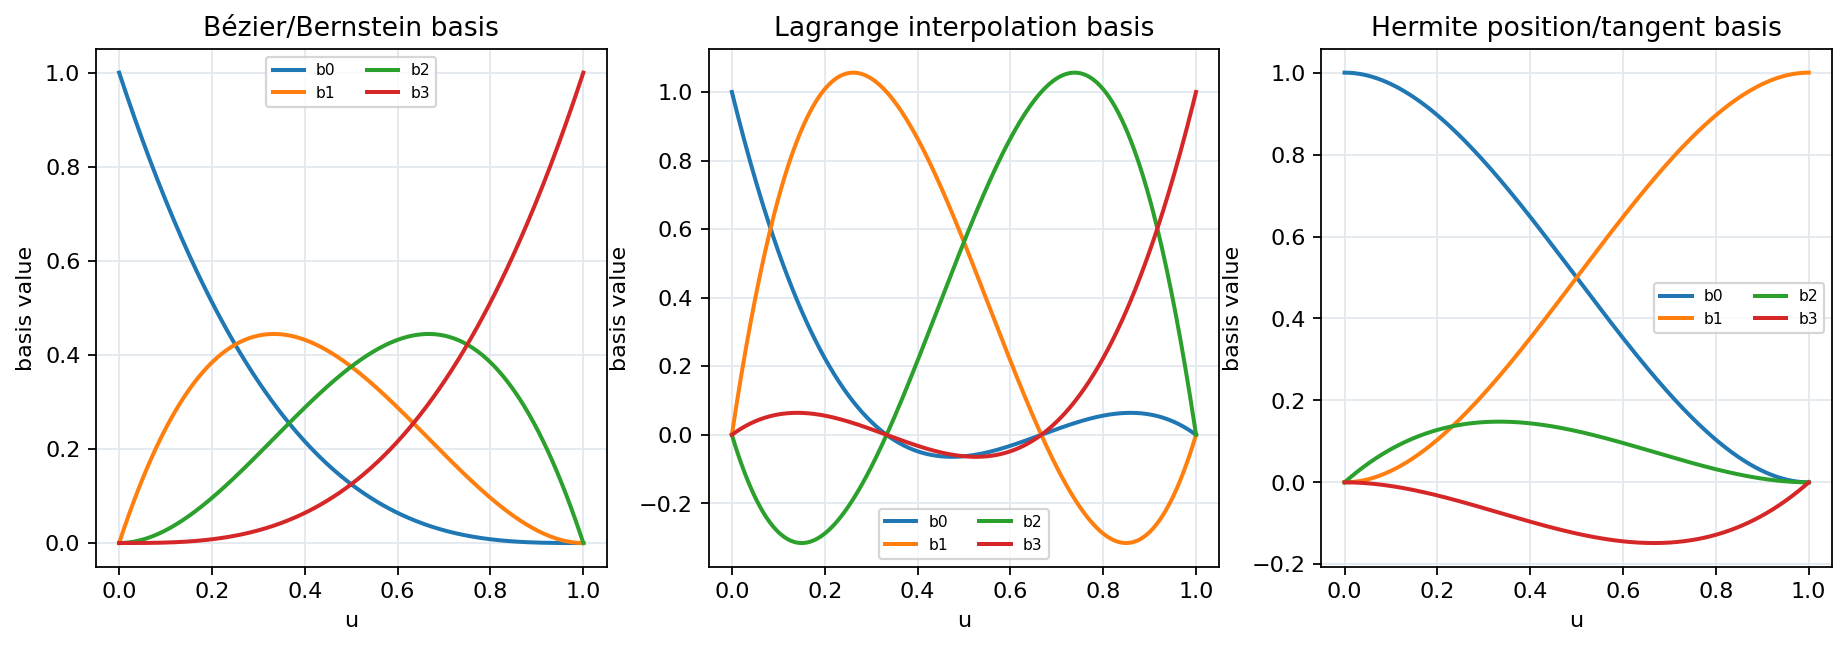

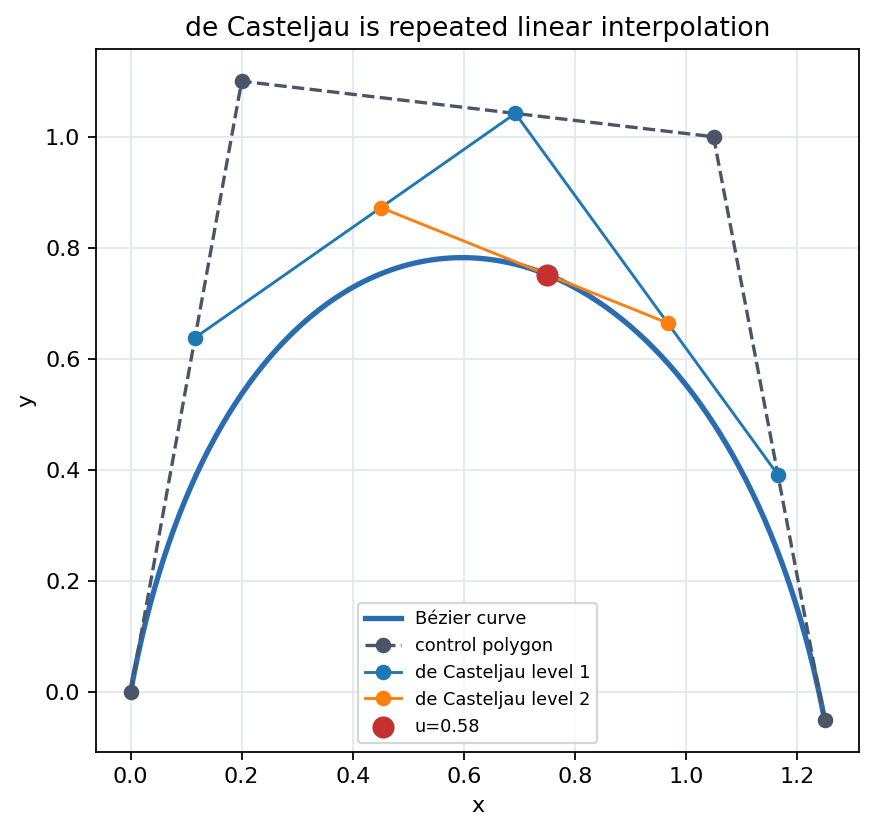

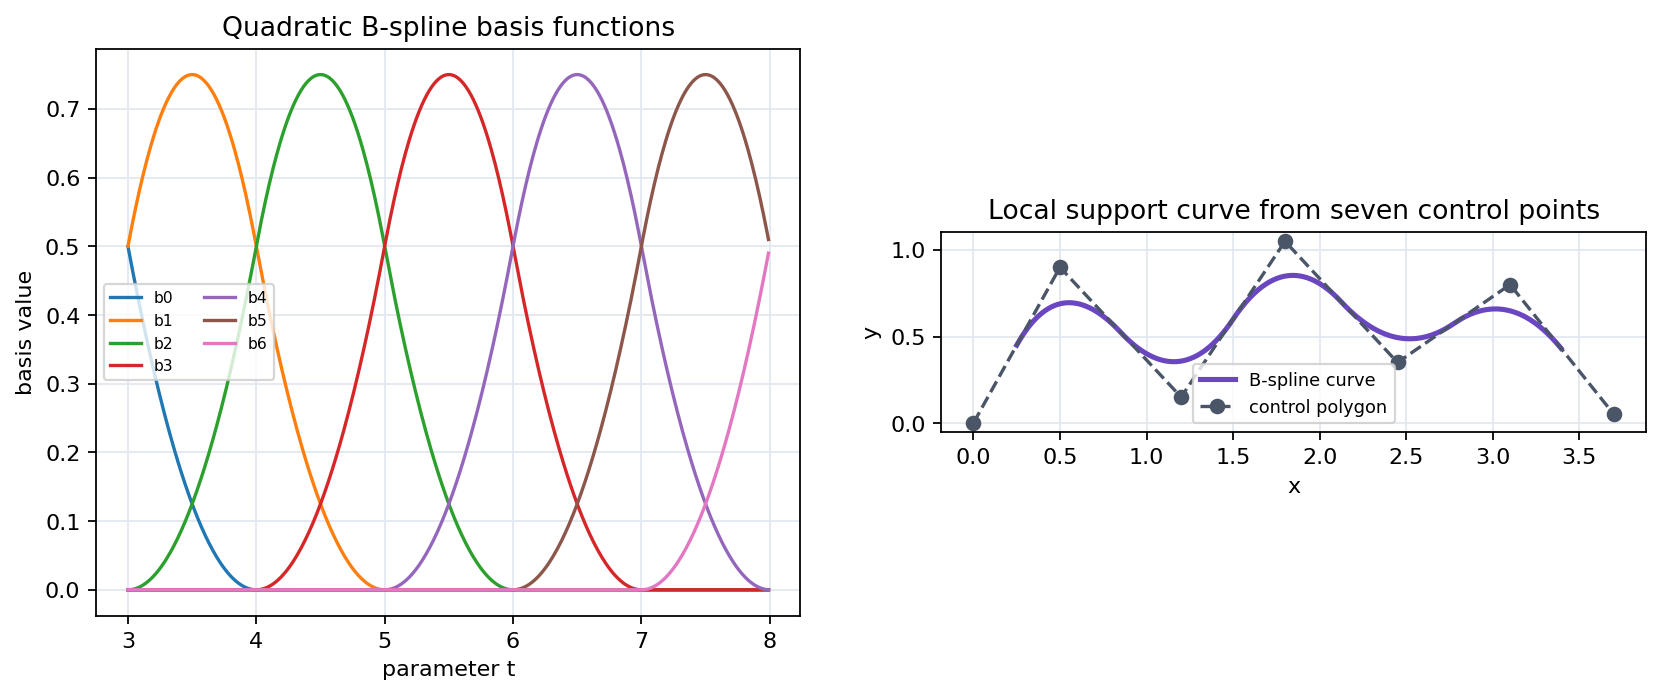

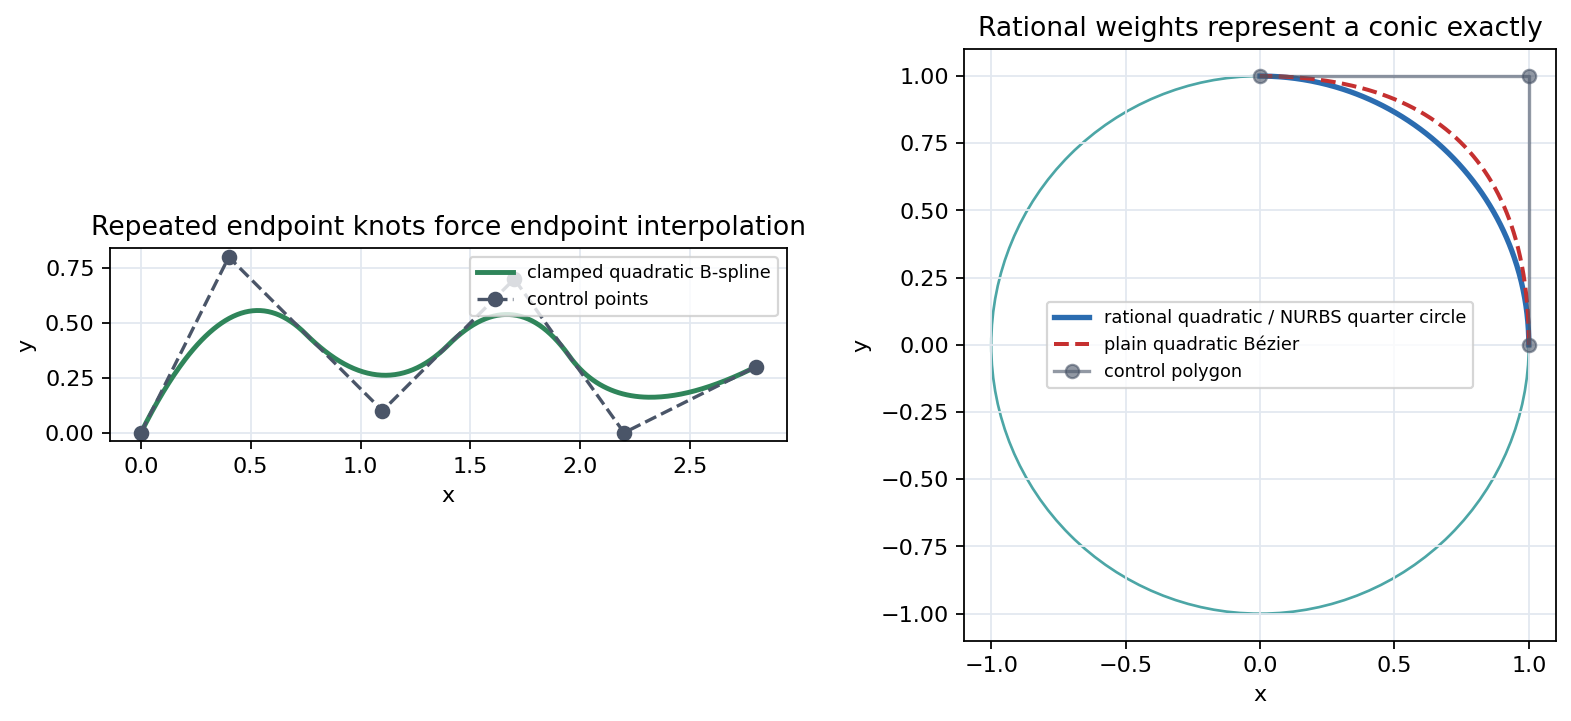

In [10]:
artifact_sequence = [*image_paths, *html_paths]
assert_artifacts(artifact_sequence)
for path in image_paths:
    display_artifact(path, width=760)
for path in html_paths:
    display_artifact(path, width="100%", height=560)


## Sanity checks

The final checks are aligned with the chapter's curve contracts: representation residuals, arc-length monotonicity, continuity residuals, basis partition of unity, de Casteljau equivalence, B-spline locality, repeated-knot interpolation, and rational conic accuracy. These are small checks, but they are the kind of checks that catch real curve bugs in modeling and rendering code.


In [11]:
assert checks["implicit_circle_parametric_residual"] < 1e-12
assert checks["arc_length_table_monotone"] is True
assert checks["arc_length_sampling_reduces_step_cv"] is True
assert checks["continuity_c0_position_zero"] is True
assert checks["continuity_g1_direction_small"] is True
assert checks["continuity_c1_derivative_small"] is True
assert checks["bernstein_partition_unity_symbolic"] is True
assert checks["lagrange_partition_unity_symbolic"] is True
assert checks["de_casteljau_bernstein_residual"] < 1e-12
assert checks["bezier_inside_control_bbox"] is True
assert checks["bspline_partition_unity_max_error"] < 1e-12
assert checks["bspline_locality_at_most_k"] is True
assert checks["clamped_bspline_start_interpolates"] is True
assert checks["nurbs_quarter_circle_radius_residual"] < 1e-12
assert checks["nurbs_more_accurate_than_plain_quadratic"] is True

image_records = [assert_nonblank_image(path) for path in image_paths]
artifact_records = assert_artifacts([*image_paths, *html_paths])
check_rows = [{"check": key, "value": str(value), "concept": "curve invariant"} for key, value in sorted(checks.items())]
ledger_path = remember(save_table_csv(check_rows, UNIT, "curve-invariant-ledger.csv"), "table")
storyboard = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "visuals": [rel_book(path) for path in image_paths + html_paths + [continuity_table, ledger_path]],
    "library_routing": {"numpy":"curve sampling, arc-length tables, basis evaluation", "sympy":"symbolic cubic basis checks", "matplotlib":"durable curve diagrams", "plotly":"interactive control lab"},
    "checks": checks,
}
storyboard_path = remember(save_json(storyboard, UNIT, "visual-storyboard.json"), "check")
checks_path = remember(save_json({"chapter": CHAPTER, "checks": checks, "image_records": image_records}, UNIT, "curve-invariants.json"), "check")
numeric_path = remember(save_json({"chapter": CHAPTER, "checks": checks}, UNIT, "numeric-checks.json"), "check")
final_report = {"chapter": CHAPTER, "title": TITLE, "printed_pages":"383-428", "pdf_pages":"400-445", "artifacts":[rel_book(path) for path in image_paths + html_paths + table_paths + check_paths], "nonblank_images": len(image_records), "checks": checks, "notebook_executed": True}
final_path = remember(save_json(final_report, UNIT, "final-sanity.json"), "check")
assert_artifacts([*check_paths, *table_paths])
display_artifact(final_path)
final_report


{'chapter': 15,
 'title': 'Curves',
 'printed_pages': '383-428',
 'pdf_pages': '400-445',
 'artifacts': ['artifacts/chapter-15/figures/curve-representation-route-map.png',
  'artifacts/chapter-15/figures/parameterization-arc-length-diagnostics.png',
  'artifacts/chapter-15/figures/piecewise-continuity-constraints.png',
  'artifacts/chapter-15/figures/cubic-basis-constraint-comparison.png',
  'artifacts/chapter-15/figures/bezier-de-casteljau-subdivision.png',
  'artifacts/chapter-15/figures/bspline-basis-locality-knots.png',
  'artifacts/chapter-15/figures/repeated-knots-nurbs-circle.png',
  'artifacts/chapter-15/html/curve-control-lab.html',
  'artifacts/chapter-15/tables/piecewise-continuity-residuals.csv',
  'artifacts/chapter-15/tables/curve-invariant-ledger.csv',
  'artifacts/chapter-15/checks/visual-storyboard.json',
  'artifacts/chapter-15/checks/curve-invariants.json',
  'artifacts/chapter-15/checks/numeric-checks.json'],
 'nonblank_images': 7,
 'checks': {'implicit_circle_param

## Takeaways

- A curve and its representation are different things; graphics code usually manipulates the representation.
- Parametric curves are easy to draw, but parameter values are not automatically distances.
- Piecewise curves need explicit continuity contracts at joins.
- Cubic bases encode constraints; changing the basis changes the editing interface, not necessarily the represented polynomial family.
- Bézier curves are controlled globally over a segment and de Casteljau evaluation makes their subdivision geometry visible.
- B-splines use local basis functions that sum to one, giving local control and translation invariance.
- Repeated knots can force interpolation but reduce smoothness.
- NURBS add rational weights, which is why they can represent conic sections such as circles exactly.
